In [ ]:
# %%
# ============================================================
# 11회차 실습 코드 - 파트 1: VAR 분석
# "변수들이 서로 영향을 준다 — VAR과 IRF"
# ============================================================
# 10회차 코드와 이어집니다.
# 파트 1을 먼저 실행한 뒤 파트 2로 넘어가세요.
# ============================================================
# %% [셀 1] 라이브러리 불러오기

# -----------------------------------------------------------
# 이번 수업에서 새로 쓰는 라이브러리가 추가됩니다.
# statsmodels 안에 VAR, VECM, 공적분 검정이 모두 들어있습니다.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller          # ADF 단위근 검정
from statsmodels.tsa.api import VAR                     # VAR 모델
from statsmodels.tsa.vector_ar.vecm import VECM         # VECM 모델
from statsmodels.tsa.vector_ar.vecm import coint_johansen  # 요한슨 공적분 검정

print("라이브러리 로드 완료!")
print("오늘 새로 쓰는 도구: VAR, VECM, coint_johansen")

라이브러리 로드 완료!
오늘 새로 쓰는 도구: VAR, VECM, coint_johansen


In [2]:

# %% [셀 2] 데이터 불러오기 및 변수 선택
# -----------------------------------------------------------
# 이번 수업에서는 울산·대산·광양 세 항만 + 유가를 함께 분석합니다.
# 세 항만이 공통된 경제 환경(유가, 환율)의 영향을 받기 때문에
# 공적분 관계가 있을 가능성이 높습니다.

# from google.colab import files
# uploaded = files.upload()   # data.csv 선택
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')   # 날짜를 인덱스로 설정 (시계열 분석에서 중요)

# 이번 수업에서 사용할 변수 선택
# 울산, 대산, 광양: 세 항만 월별 물동량
# Oil_Price: 국제 유가 (외부 충격 변수)
vars_use = ['Ulsan', 'Daesan', 'Gwangyang', 'Oil_Price']
data = df[vars_use].copy()

print(f"분석 변수: {vars_use}")
print(f"데이터 기간: {data.index[0].date()} ~ {data.index[-1].date()}")
print(f"관측치 수: {len(data)}")
print()
print(data.head())


분석 변수: ['Ulsan', 'Daesan', 'Gwangyang', 'Oil_Price']
데이터 기간: 2015-01-01 ~ 2025-12-01
관측치 수: 132

             Ulsan  Daesan  Gwangyang  Oil_Price
Date                                            
2015-01-01  1452.1   721.4     1125.0       47.3
2015-02-01  1332.2   660.5     1030.4       54.2
2015-03-01  1489.2   739.5     1154.6       52.5
2015-04-01  1489.7   738.3     1156.4       57.1
2015-05-01  1526.4   760.1     1184.5       62.3


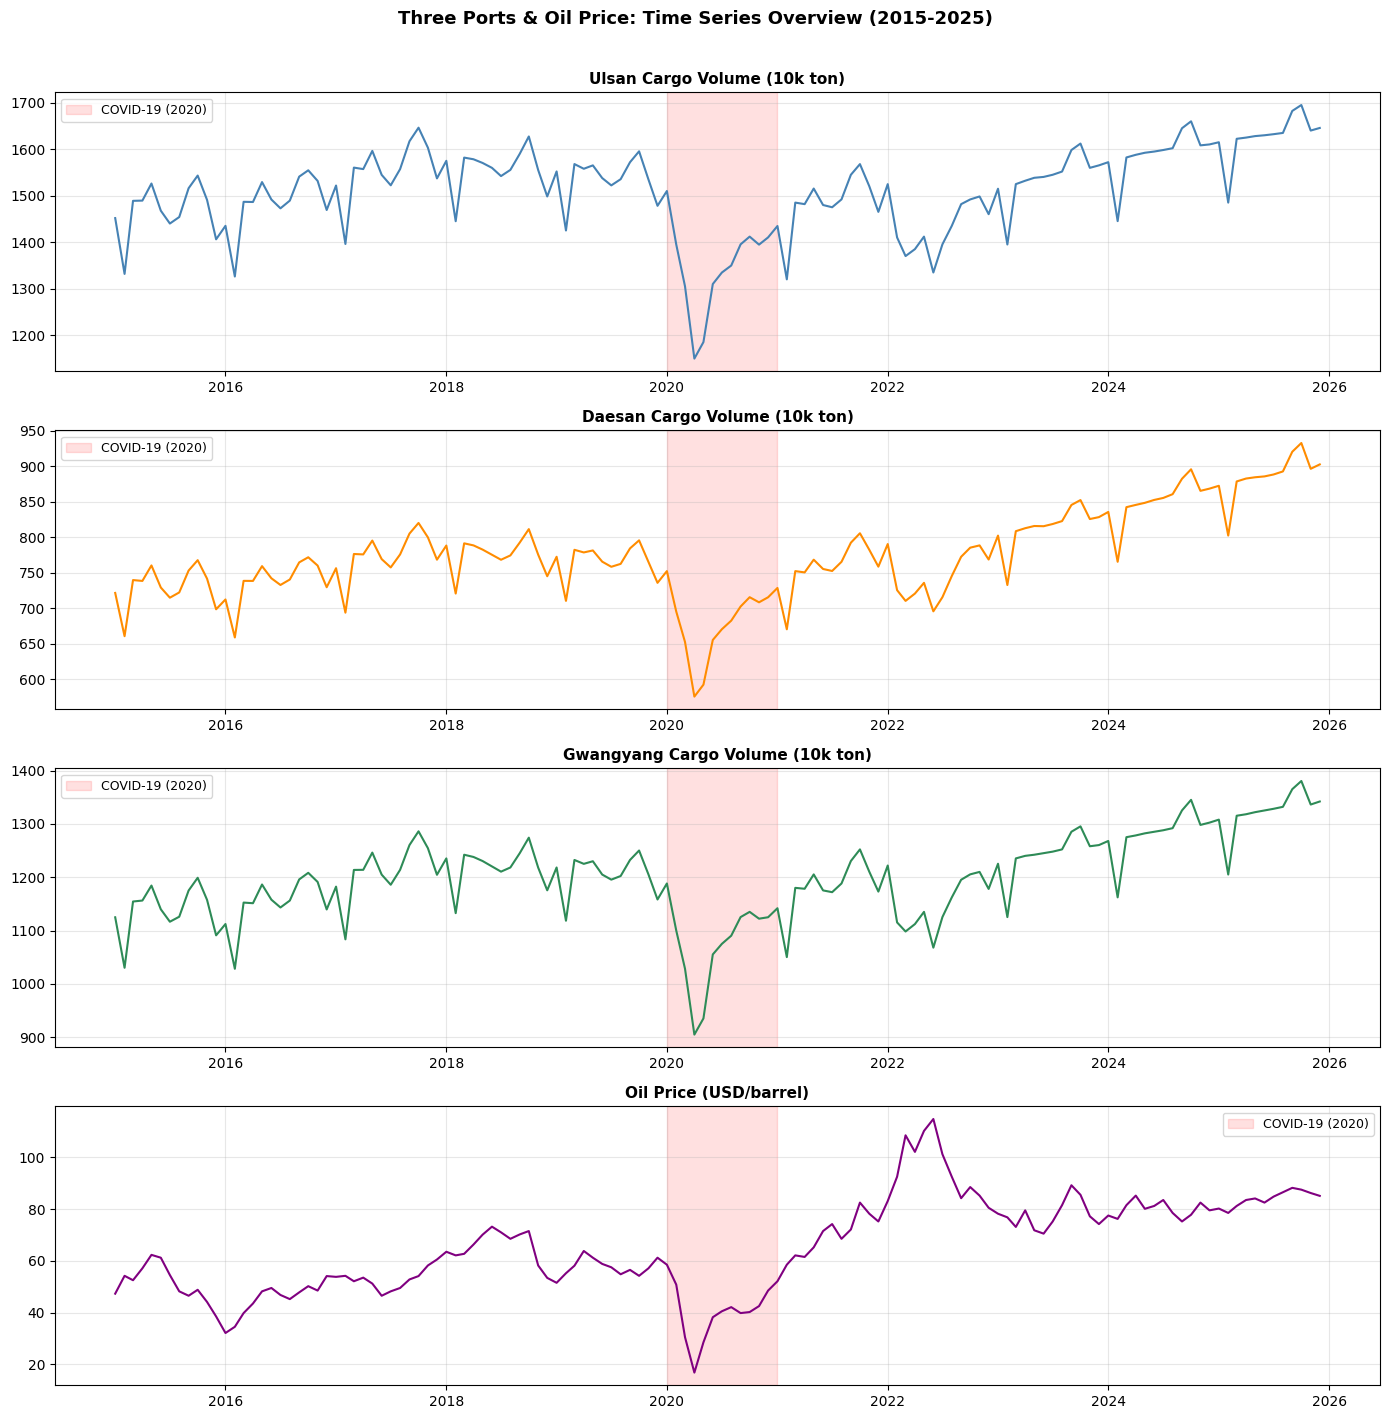


[관찰 포인트]
□ 세 항만이 비슷한 방향으로 움직이는가? (공적분 가능성)
□ 유가와 물동량이 반대로 움직이는 구간이 있는가?
□ 2020년 충격이 세 항만에 동시에 나타나는가?


In [3]:

# %% [셀 3] 시계열 시각화 - 네 변수 한눈에 보기
# -----------------------------------------------------------
# 분석 전에 각 변수의 흐름을 눈으로 확인합니다.
# 세 항만이 비슷한 방향으로 움직이는지 주목합니다.
# 비슷하게 움직인다면 공적분 관계일 가능성이 있습니다.

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

plot_info = [
    ('Ulsan',        'steelblue',  'Ulsan Cargo Volume (10k ton)'),
    ('Daesan',       'darkorange', 'Daesan Cargo Volume (10k ton)'),
    ('Gwangyang',    'seagreen',   'Gwangyang Cargo Volume (10k ton)'),
    ('Oil_Price',  'purple',     'Oil Price (USD/barrel)'),
]

for ax, (col, color, title) in zip(axes, plot_info):
    ax.plot(data.index, data[col], color=color, linewidth=1.5)
    # 2020년 코로나 구간 음영
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'),
               alpha=0.12, color='red', label='COVID-19 (2020)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Three Ports & Oil Price: Time Series Overview (2015-2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n[관찰 포인트]")
print("□ 세 항만이 비슷한 방향으로 움직이는가? (공적분 가능성)")
print("□ 유가와 물동량이 반대로 움직이는 구간이 있는가?")
print("□ 2020년 충격이 세 항만에 동시에 나타나는가?")


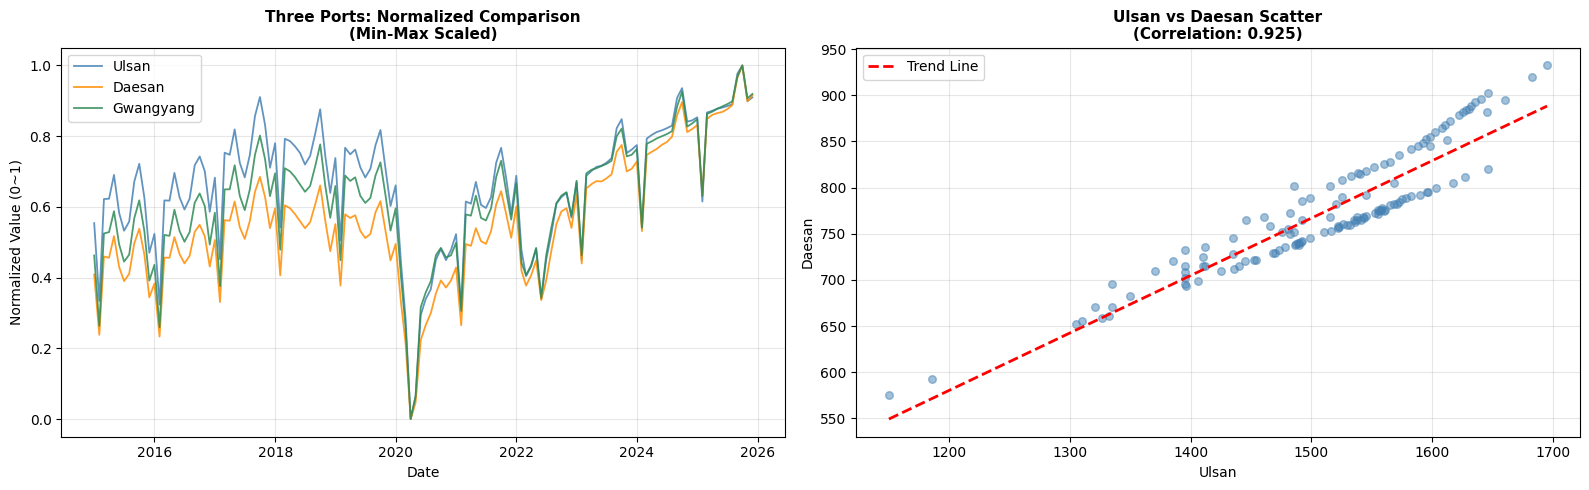


[해석 포인트]
왼쪽: 세 항만의 움직임이 얼마나 비슷한가?
오른쪽: 울산과 대산 사이에 선형 관계가 있는가?
울산-대산 상관계수: 0.925
울산-광양 상관계수: 0.970
대산-광양 상관계수: 0.983


In [4]:

# %% [셀 4] 세 항만 물동량 비교 - 공적분 직관 확인
# -----------------------------------------------------------
# 세 항만을 같은 그래프에 겹쳐서 그려봅니다.
# 서로 비슷하게 움직인다면 "함께 묶여있다"는 직관을 얻을 수 있습니다.
# 이것이 공적분의 시각적 근거입니다.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- 왼쪽: 원계열 비교 ---
# 단위가 달라서 직접 비교가 어려울 수 있으므로
# 표준화(0~1 스케일)해서 겹쳐 그립니다.
for col, color in zip(['Ulsan', 'Daesan', 'Gwangyang'],
                      ['steelblue', 'darkorange', 'seagreen']):
    # Min-Max 표준화: (값 - 최솟값) / (최댓값 - 최솟값)
    normalized = (data[col] - data[col].min()) / (data[col].max() - data[col].min())
    axes[0].plot(data.index, normalized, color=color,
                 linewidth=1.3, alpha=0.85, label=col)

axes[0].set_title('Three Ports: Normalized Comparison\n(Min-Max Scaled)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Normalized Value (0~1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 오른쪽: 울산-대산 산점도 (공적분이면 선형 관계가 보임) ---
axes[1].scatter(data['Ulsan'], data['Daesan'],
                color='steelblue', alpha=0.5, s=30)

# 추세선 추가
z = np.polyfit(data['Ulsan'], data['Daesan'], 1)
p = np.poly1d(z)
x_line = np.linspace(data['Ulsan'].min(), data['Ulsan'].max(), 100)
axes[1].plot(x_line, p(x_line), color='red',
             linestyle='--', linewidth=2, label='Trend Line')

corr = data['Ulsan'].corr(data['Daesan'])
axes[1].set_title(f'Ulsan vs Daesan Scatter\n(Correlation: {corr:.3f})',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ulsan')
axes[1].set_ylabel('Daesan')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[해석 포인트]")
print("왼쪽: 세 항만의 움직임이 얼마나 비슷한가?")
print("오른쪽: 울산과 대산 사이에 선형 관계가 있는가?")
print(f"울산-대산 상관계수: {data['Ulsan'].corr(data['Daesan']):.3f}")
print(f"울산-광양 상관계수: {data['Ulsan'].corr(data['Gwangyang']):.3f}")
print(f"대산-광양 상관계수: {data['Daesan'].corr(data['Gwangyang']):.3f}")


In [5]:

# %% [셀 5] ADF 단위근 검정 재확인
# -----------------------------------------------------------
# 10회차에서 배운 ADF 검정을 이번 변수들에 다시 적용합니다.
# VAR/VECM을 쓰기 전에 반드시 확인해야 합니다.
# 모든 변수가 I(1)이어야 공적분 검정으로 넘어갈 수 있습니다.

def run_adf(series, name, verbose=True):
    """ADF 검정 실행 함수 (10회차와 동일)"""
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    is_stationary = p_value < 0.05
    if verbose:
        status = "✅ 정상" if is_stationary else "❌ 비정상"
        print(f"  {name:<20} p={p_value:.4f}  {status}")
    return p_value, is_stationary

print("=" * 55)
print("  [원계열 ADF 검정]")
print("=" * 55)
results_orig = {}
for col in vars_use:
    p, stat = run_adf(data[col], col)
    results_orig[col] = (p, stat)

print()
print("=" * 55)
print("  [1차 차분 후 ADF 검정]")
print("=" * 55)
results_diff = {}
for col in vars_use:
    p, stat = run_adf(data[col].diff(), f'd({col})')
    results_diff[col] = (p, stat)

print()
print("=" * 55)
print("  [단위근 검정 요약]")
print("=" * 55)
all_i1 = True
for col in vars_use:
    orig_stat = results_orig[col][1]
    diff_stat = results_diff[col][1]
    if not orig_stat and diff_stat:
        order = "I(1) ✅"
    elif orig_stat:
        order = "I(0) - 이미 정상"
        all_i1 = False
    else:
        order = "I(2)+ - 추가 차분 필요"
        all_i1 = False
    print(f"  {col:<20} {order}")

print()
if all_i1:
    print("→ 모든 변수가 I(1)입니다.")
    print("  공적분 검정(요한슨 검정)으로 진행합니다.")
else:
    print("→ 차수가 다른 변수가 있습니다. 공적분 검정 전 확인 필요.")


  [원계열 ADF 검정]
  Ulsan                p=0.5342  ❌ 비정상
  Daesan               p=0.8924  ❌ 비정상
  Gwangyang            p=0.7530  ❌ 비정상
  Oil_Price            p=0.4108  ❌ 비정상

  [1차 차분 후 ADF 검정]
  d(Ulsan)             p=0.0289  ✅ 정상
  d(Daesan)            p=0.0369  ✅ 정상
  d(Gwangyang)         p=0.0283  ✅ 정상
  d(Oil_Price)         p=0.0000  ✅ 정상

  [단위근 검정 요약]
  Ulsan                I(1) ✅
  Daesan               I(1) ✅
  Gwangyang            I(1) ✅
  Oil_Price            I(1) ✅

→ 모든 변수가 I(1)입니다.
  공적분 검정(요한슨 검정)으로 진행합니다.


In [6]:

# %% [셀 6] 최적 시차 선택 - VAR용
# -----------------------------------------------------------
# VAR 모델을 만들기 전에 몇 기 시차를 쓸지 결정합니다.
# AIC, BIC, HQIC 세 가지 기준이 동시에 나옵니다.
# 기준들이 일치하는 시차를 선택합니다.
#
# 잠깐! 여기서는 차분된 데이터를 씁니다.
# 공적분이 없는 경우를 대비해서 VAR용 최적 시차를 먼저 구합니다.
# 공적분이 있으면 이 시차를 VECM에서도 참고합니다.

# 1차 차분 데이터 준비
data_diff = data.diff().dropna()
# .dropna(): 차분하면 첫 번째 행이 NaN이 되므로 제거

# VAR 모델 객체 생성 (시차 선택용)
var_model = VAR(data_diff)

# 최적 시차 선택 (최대 12기까지 탐색)
lag_order = var_model.select_order(maxlags=12)
print("=" * 50)
print("  최적 시차 선택 결과")
print("=" * 50)
print(lag_order.summary())

# 각 기준별 추천 시차 출력
aic_lag = lag_order.aic
bic_lag = lag_order.bic
hqic_lag = lag_order.hqic

print(f"\nAIC 추천 시차: {aic_lag}")
print(f"BIC 추천 시차: {bic_lag}")
print(f"HQIC 추천 시차: {hqic_lag}")

# 최종 시차 결정 (여러 기준 중 최빈값 또는 AIC 우선)
from collections import Counter
votes = Counter([aic_lag, bic_lag, hqic_lag])
selected_lag = votes.most_common(1)[0][0]
print(f"\n→ 선택된 시차: {selected_lag}기 (다수결 기준)")
print("  (기준들이 다를 경우 AIC를 우선합니다)")
selected_lag = max(selected_lag, 1)  # 최소 1기 보장


  최적 시차 선택 결과
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        16.41      16.51*   1.341e+07       16.45
1        16.11       16.58   9.906e+06      16.30*
2        16.23       17.07   1.118e+07       16.57
3        16.37       17.58   1.285e+07       16.86
4        16.29       17.88   1.197e+07       16.93
5        16.31       18.27   1.231e+07       17.11
6        16.33       18.66   1.265e+07       17.28
7        16.39       19.10   1.368e+07       17.49
8        16.50       19.59   1.560e+07       17.75
9        16.54       20.00   1.666e+07       17.95
10       16.60       20.43   1.815e+07       18.15
11       16.37       20.57   1.503e+07       18.07
12      15.77*       20.35  8.688e+06*       17.63
--------------------------------------------------

AIC 추천 시차: 12
BIC 추천 시차: 0
HQIC 추천 시차: 1

→ 선택된 시차: 12기 (다수결 기준)
  (기준들이 다를 경우 AIC를 우선합니다)


/Users/giveroot/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:

# %% [셀 7] VAR 모델 적합 및 결과 확인
# -----------------------------------------------------------
# 선택된 시차로 VAR 모델을 적합합니다.
# VAR 결과표는 매우 길기 때문에 전체를 읽기보다
# IRF와 FEVD를 통해 결과를 해석합니다.

var_result = var_model.fit(selected_lag)

# 결과 요약 (길기 때문에 일부만 확인)
print("VAR 모델 적합 완료")
print(f"사용 시차: {selected_lag}기")
print(f"관측치 수: {var_result.nobs}")
print()

print(var_result.summary())  # 전체 결과표 출력 (길어서 주석 처리)
# for i, col in enumerate(vars_use):
#     print(f"  {col:<20} R² = {var_result.rsquared[i]:.4f}")


VAR 모델 적합 완료
사용 시차: 12기
관측치 수: 119

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 14, Mar, 2026
Time:                     22:35:35
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    20.3471
Nobs:                     119.000    HQIC:                   17.6285
Log likelihood:          -1417.72    FPE:                8.68850e+06
AIC:                      15.7698    Det(Omega_mle):     2.18723e+06
--------------------------------------------------------------------
Results for equation Ulsan
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                -3.113583         6.378731           -0.488           0.625
L1.Ulsan             -0.700673         1.429792           -0.490           0.624
L1.Daesan            -0.

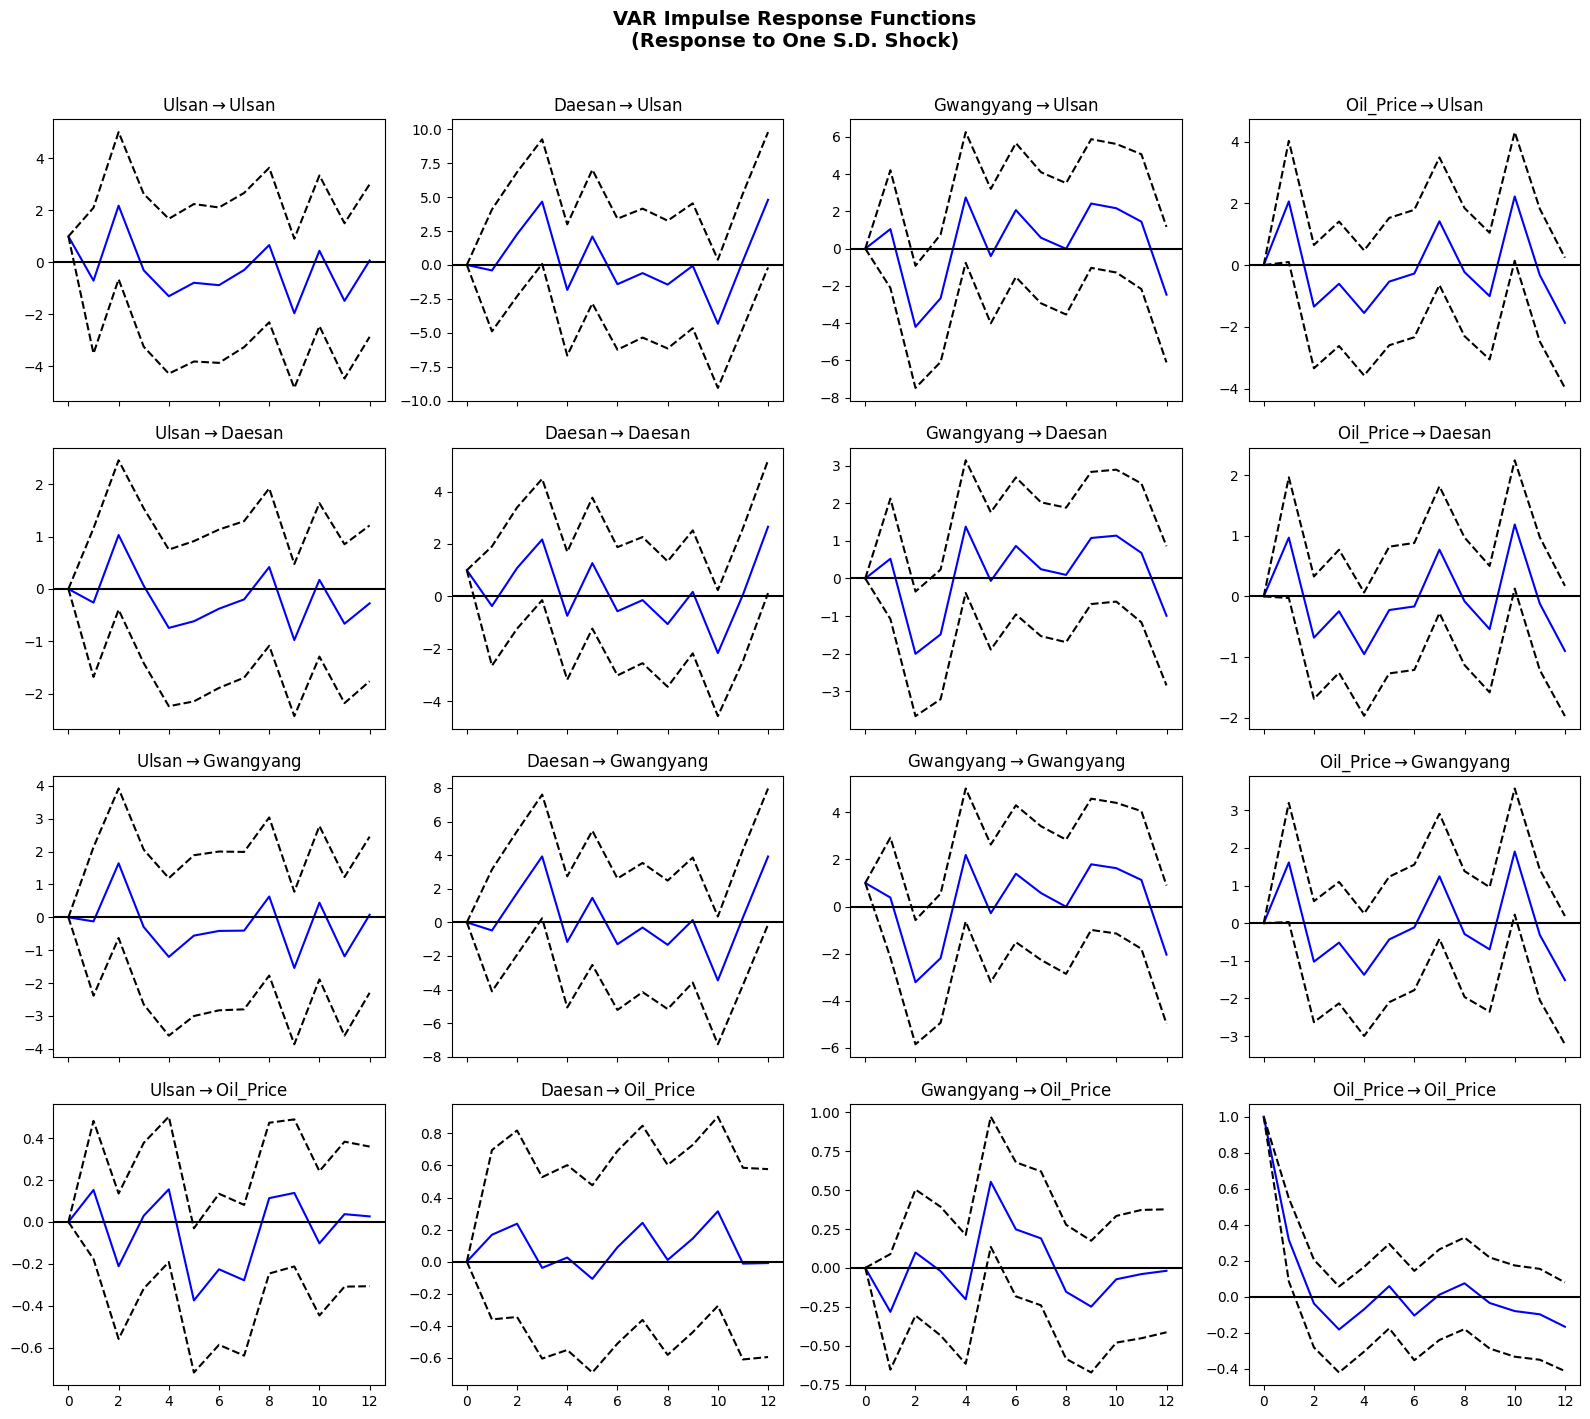

In [ ]:

# %% [셀 8] IRF - 충격반응함수 시각화
# -----------------------------------------------------------
# VAR 분석의 핵심 결과물입니다.
# "유가에 충격이 왔을 때 세 항만이 어떻게 반응하는가"를 그래프로 봅니다.
#
# [그래프 읽는 법]
# X축: 충격 후 몇 개월이 지났는가 (시차)
# Y축: 반응의 크기 (양수=같은 방향, 음수=반대 방향)
# 점선: 95% 신뢰구간 (점선이 0을 포함하지 않으면 유의)
# 실선이 0에 수렴할수록 충격이 사라지는 것

# IRF 계산 (12기간 = 12개월 후까지 추적)
irf = var_result.irf(periods=12)

# 전체 IRF 그리기 (4×4 행렬)
# 행: 반응하는 변수 / 열: 충격을 받은 변수
fig = irf.plot(orth=False, figsize=(16, 14))
fig.suptitle('VAR Impulse Response Functions\n(Response to One S.D. Shock)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


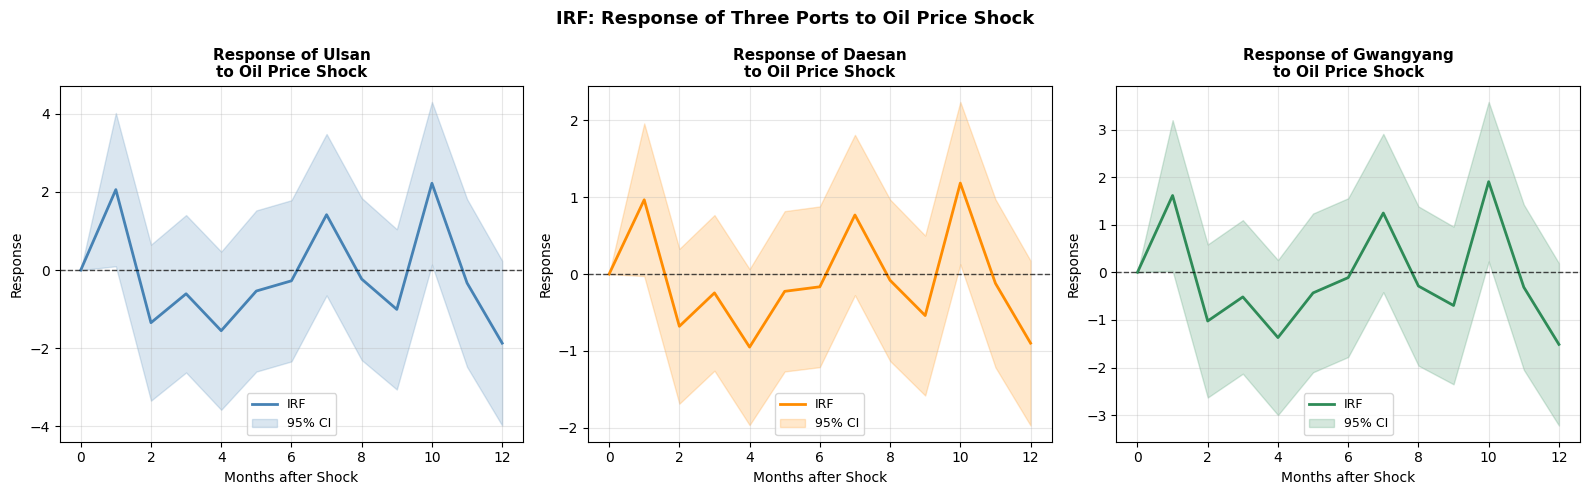


[그래프 해석 체크리스트]
□ 각 항만이 유가 충격에 양(+)으로 반응하는가, 음(-)으로 반응하는가?
□ 반응이 나타나기까지 몇 개월의 시차가 있는가?
□ 신뢰구간(음영)이 0을 포함하지 않는 구간이 있는가? (유의한 반응)
□ 충격이 몇 개월 후에 0으로 수렴하는가?


In [ ]:

# %% [셀 9] IRF - 유가 충격에 대한 반응만 따로 보기
# -----------------------------------------------------------
# 논문 관점에서 가장 중요한 것은
# "유가(Oil_Price) 충격에 대한 각 항만의 반응"입니다.
# 이것만 따로 크게 그려서 자세히 봅니다.

periods = 12   # 12개월 후까지 추적
irf_data = irf.irfs   # shape: (periods+1, n_vars, n_vars)

# 유가의 인덱스 찾기
oil_idx = vars_use.index('Oil_Price')
port_vars = ['Ulsan', 'Daesan', 'Gwangyang']
port_colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, port, color in zip(axes, port_vars, port_colors):
    port_idx = vars_use.index(port)

    # IRF 값 추출 (유가 → 해당 항만)
    irf_vals = irf_data[:periods+1, port_idx, oil_idx]

    # 신뢰구간 계산
    irf_stderr = irf.stderr(orth=False)
    upper = irf_vals + 1.96 * irf_stderr[:periods+1, port_idx, oil_idx]
    lower = irf_vals - 1.96 * irf_stderr[:periods+1, port_idx, oil_idx]

    time_axis = range(periods + 1)

    # IRF 선 그리기
    ax.plot(time_axis, irf_vals, color=color,
            linewidth=2, label='IRF')

    # 신뢰구간 음영
    ax.fill_between(time_axis, lower, upper,
                    alpha=0.2, color=color, label='95% CI')

    # 0 기준선
    ax.axhline(y=0, color='black', linestyle='--',
               linewidth=1, alpha=0.7)

    ax.set_title(f'Response of {port}\nto Oil Price Shock',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Months after Shock')
    ax.set_ylabel('Response')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('IRF: Response of Three Ports to Oil Price Shock',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[그래프 해석 체크리스트]")
print("□ 각 항만이 유가 충격에 양(+)으로 반응하는가, 음(-)으로 반응하는가?")
print("□ 반응이 나타나기까지 몇 개월의 시차가 있는가?")
print("□ 신뢰구간(음영)이 0을 포함하지 않는 구간이 있는가? (유의한 반응)")
print("□ 충격이 몇 개월 후에 0으로 수렴하는가?")


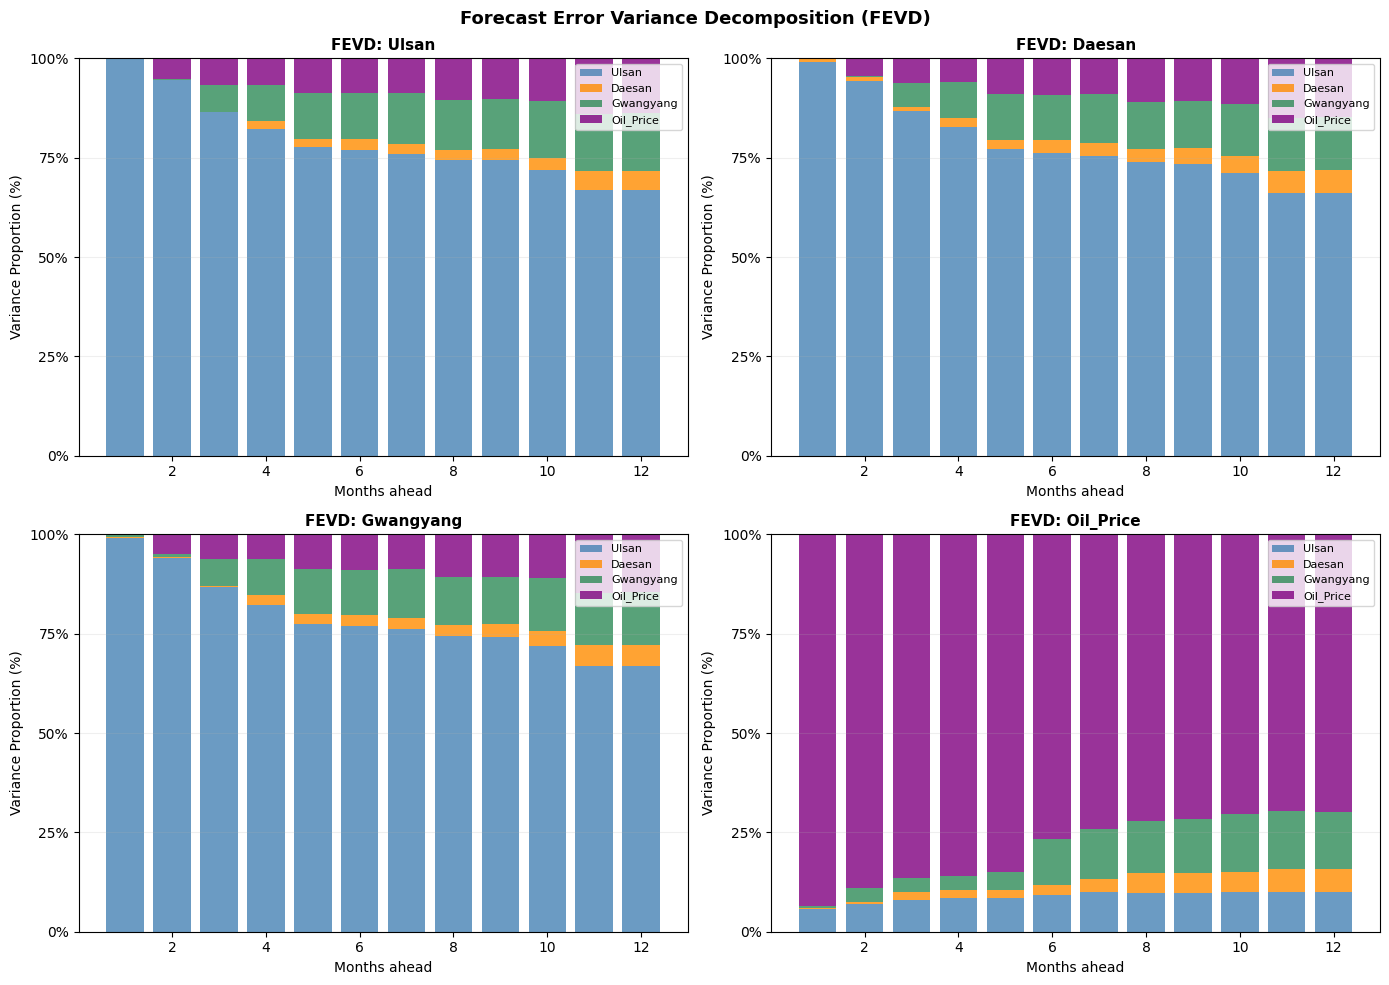

=== FEVD 수치 결과: 울산(Ulsan) 물동량 ===
  시차       Ulsan      Daesan   Gwangyang      OilPrc
-------------------------------------------------------
   1기      100.0%        0.0%        0.0%        0.0%
   3기       86.4%        0.0%        6.9%        6.7%
   6기       77.0%        2.6%       11.5%        8.8%
   9기       74.3%        2.9%       12.5%       10.4%
  12기       66.8%        4.9%       14.4%       13.8%


In [ ]:

# %% [셀 10] FEVD - 분산분해
# -----------------------------------------------------------
# 각 변수의 변동이 어디서 왔는지 비율로 분해합니다.
# 울산 물동량 변동의 몇 %가 유가 때문인지를 시차별로 봅니다.

fevd = var_result.fevd(periods=12)

# FEVD 그래프
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, ax) in enumerate(zip(vars_use, axes)):
    fevd_vals = fevd.decomp[i]  # shape: (periods, n_vars)

    # 누적 막대 그래프로 표현
    bottom = np.zeros(len(fevd_vals))
    colors_fevd = ['steelblue', 'darkorange', 'seagreen', 'purple']

    for j, (var_name, fc) in enumerate(zip(vars_use, colors_fevd)):
        values = fevd_vals[:, j]
        ax.bar(range(1, len(values)+1), values,
               bottom=bottom, color=fc, alpha=0.8,
               label=var_name.replace('Oil_Price', 'Oil_Price'))
        bottom += values

    ax.set_title(f'FEVD: {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Months ahead')
    ax.set_ylabel('Variance Proportion (%)')
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Forecast Error Variance Decomposition (FEVD)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 수치 표로도 확인 (울산 물동량만)
print("=== FEVD 수치 결과: 울산(Ulsan) 물동량 ===")
ulsan_idx = vars_use.index('Ulsan')
fevd_ulsan = fevd.decomp[ulsan_idx]
header = f"{'시차':>4}  " + "  ".join(f"{v.replace('Oil_Price','OilPrc'):>10}" for v in vars_use)
print(header)
print("-" * 55)
for t in [0, 2, 5, 8, 11]:
    row = f"{t+1:>4}기  "
    row += "  ".join(f"{fevd_ulsan[t, j]*100:>9.1f}%" for j in range(len(vars_use)))
    print(row)

In [ ]:
# %%
# ============================================================
# 11회차 실습 코드 - 파트 2: 공적분 검정 & VECM
# "장기 균형 관계가 있는가? 있다면 VECM으로 분석한다"
# ============================================================
# 파트 1 코드를 먼저 실행한 뒤 이어서 실행하세요.
# data, vars_use, selected_lag 변수가 이미 만들어져 있어야 합니다.
# ============================================================

# %% [셀 11] 요한슨 공적분 검정
# -----------------------------------------------------------
# 변수들 사이에 장기 균형 관계(공적분)가 있는지 확인합니다.
#
# [검정 원리]
# 공적분 벡터가 0개인지 → 1개 이상인지 → 2개 이상인지...
# 순서대로 검정합니다.
#
# [결과 읽는 법]
# trace 통계량 > 임계값(5%) → 귀무가설 기각 → 공적분 있음
# 또는 p-value < 0.05 → 공적분 있음
#
# det_order: 상수항 처리 방식
#   -1: 상수항 없음
#    0: 공적분 관계에만 상수항 포함 (가장 일반적)
#    1: 모든 방정식에 상수항 포함
# k_ar_diff: 시차 수 (VAR 시차 - 1)

# 원계열 데이터로 검정 (공적분은 수준 변수로 검정)
johansen_result = coint_johansen(
    data[['Ulsan', 'Daesan', 'Gwangyang', 'Oil_Price']],
    det_order=0,           # 공적분 관계에 상수항 포함
    k_ar_diff=selected_lag # 앞에서 선택한 시차 적용
)

print("=" * 60)
print("  요한슨 공적분 검정 결과 (Johansen Cointegration Test)")
print("=" * 60)
print()

# Trace 통계량 결과
print("--- Trace 통계량 ---")
print(f"{'귀무가설':<25} {'Trace통계량':>12} {'임계값(5%)':>12} {'판정':>10}")
print("-" * 60)

n_vars = len(vars_use)
trace_stats  = johansen_result.lr1   # Trace 통계량
trace_crits  = johansen_result.cvt   # 임계값 (90%, 95%, 99%)
# cvt 열: 0=90%, 1=95%, 2=99%

coint_rank = 0  # 공적분 벡터 수 (검정 결과로 결정)

for i in range(n_vars):
    h0 = f"공적분 벡터 ≤ {i}개"
    stat   = trace_stats[i]
    crit95 = trace_crits[i, 1]   # 95% 임계값
    reject = stat > crit95
    judgment = "기각 → 공적분 있음 ✅" if reject else "채택 → 공적분 없음"
    print(f"{h0:<25} {stat:>12.4f} {crit95:>12.4f} {judgment:>10}")
    if reject:
        coint_rank = i + 1

print()
print(f"→ 확인된 공적분 벡터 수: {coint_rank}개")
print()

# 판정 결과에 따라 모델 선택
if coint_rank > 0:
    print("공적분 관계가 존재합니다.")
    print(f"→ VECM을 사용합니다. (공적분 벡터: {coint_rank}개)")
    use_vecm = True
else:
    print("공적분 관계가 없습니다.")
    print("→ 차분 후 VAR을 사용합니다.")
    use_vecm = False


  요한슨 공적분 검정 결과 (Johansen Cointegration Test)

--- Trace 통계량 ---
귀무가설                          Trace통계량      임계값(5%)         판정
------------------------------------------------------------
공적분 벡터 ≤ 0개                    58.2374      47.8545 기각 → 공적분 있음 ✅
공적분 벡터 ≤ 1개                    26.4936      29.7961 채택 → 공적분 없음
공적분 벡터 ≤ 2개                    10.6385      15.4943 채택 → 공적분 없음
공적분 벡터 ≤ 3개                     2.7097       3.8415 채택 → 공적분 없음

→ 확인된 공적분 벡터 수: 1개

공적분 관계가 존재합니다.
→ VECM을 사용합니다. (공적분 벡터: 1개)


In [ ]:

# %% [셀 12] 분석 경로 분기
# -----------------------------------------------------------
# 공적분 검정 결과에 따라 두 경로로 나뉩니다.
#
# 경로 A: 공적분 있음 → VECM (셀 13~16)
# 경로 B: 공적분 없음 → 차분 VAR은 셀 7~10에서 이미 완료
#
# 수업에서는 두 경로를 모두 실행해봅니다.
# 결과를 비교하면서 "왜 VECM을 써야 하는가"를 체험합니다.

print("=" * 50)
if use_vecm:
    print("  → 경로 A: VECM 분석으로 진행합니다")
else:
    print("  → 경로 B: VAR 결과(셀 7~10)를 최종 결과로 사용합니다")
print("=" * 50)


  → 경로 A: VECM 분석으로 진행합니다


In [ ]:

# %% [셀 13] VECM 모델 적합
# -----------------------------------------------------------
# 공적분이 확인된 경우, VECM을 적합합니다.
#
# VECM의 주요 파라미터:
# k_ar_diff: 차분 시차 수 (VAR 시차 - 1)
# coint_rank: 공적분 벡터 수 (요한슨 검정 결과)
# deterministic: 상수항/추세 처리 방식
#   'ci': 공적분 관계에만 상수항 (가장 일반적)
#   'co': 모든 방정식에 상수항
#
# VECM의 시차는 VAR 시차보다 1 작습니다.
# VAR(p)는 VECM(p-1)과 동일한 정보를 씁니다.

vecm_lag = max(selected_lag - 1, 1)   # 최소 1 보장

vecm_model = VECM(
    data[['Ulsan', 'Daesan', 'Gwangyang', 'Oil_Price']],
    k_ar_diff=vecm_lag,
    coint_rank=coint_rank,
    deterministic='ci'
)

vecm_result = vecm_model.fit()

print("VECM 모델 적합 완료")
print(f"사용 시차(k_ar_diff): {vecm_lag}")
print(f"공적분 벡터 수: {coint_rank}")
print()

# 결과 요약 출력
print(vecm_result.summary())


VECM 모델 적합 완료
사용 시차(k_ar_diff): 11
공적분 벡터 수: 1

Det. terms outside the coint. relation & lagged endog. parameters for equation Ulsan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.Ulsan          1.9709      1.397      1.411      0.158      -0.767       4.709
L1.Daesan        -4.8825      2.197     -2.222      0.026      -9.189      -0.576
L1.Gwangyang      0.2601      1.526      0.170      0.865      -2.730       3.251
L1.Oil_Price      2.8690      0.975      2.942      0.003       0.957       4.781
L2.Ulsan          2.2666      1.525      1.487      0.137      -0.721       5.255
L2.Daesan        -2.6054      2.498     -1.043      0.297      -7.501       2.290
L2.Gwangyang     -1.2893      1.735     -0.743      0.457      -4.689       2.110
L2.Oil_Price     -1.1037      0.980     -1.127      0.260      -3.024       0.816
L3.Ulsan          2.6921      1.535      1.753 

/Users/giveroot/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:

# %% [셀 14] 오차수정항(ECT) 핵심 결과 추출
# -----------------------------------------------------------
# VECM 결과표에서 가장 중요한 부분은 오차수정항(ECT)입니다.
# ECT 계수의 부호와 유의성을 집중해서 확인합니다.
#
# [판단 기준]
# ECT 계수 < 0 이고 p-value < 0.05
# → 장기 균형으로의 유의한 수렴 ✅
# → "이 변수는 균형 이탈 시 교정 역할을 한다"
#
# ECT 계수 ≥ 0 또는 p-value ≥ 0.05
# → 장기 균형 수렴 없음
# → "이 변수는 균형 이탈에 반응하지 않는다"

print("=" * 60)
print("  오차수정항(ECT) 요약")
print("=" * 60)
print(f"{'변수':<20} {'ECT 계수':>12} {'t-통계량':>12} {'판정':>20}")
print("-" * 60)

# VECM 결과에서 ECT 계수 추출
# alpha: 조정속도 행렬 (각 변수의 ECT 계수)
alpha = vecm_result.alpha   # shape: (n_vars, coint_rank)

# t-통계량 계산을 위한 표준오차
# vecm_result.stderr_alpha에서 추출
try:
    stderr_alpha = vecm_result.stderr_alpha
    t_stats = alpha / stderr_alpha
except:
    t_stats = np.full_like(alpha, np.nan)

port_names = ['Ulsan', 'Daesan', 'Gwangyang', 'Oil_Price']

for i, name in enumerate(port_names):
    coef = alpha[i, 0]   # 첫 번째 공적분 벡터의 계수
    t_stat = t_stats[i, 0] if not np.isnan(t_stats[i, 0]) else 0

    # 간단한 유의성 판단 (t > 1.96 이면 5% 유의)
    is_sig = abs(t_stat) > 1.96
    is_neg = coef < 0

    if is_sig and is_neg:
        judgment = "✅ 유의한 균형 복귀"
    elif is_sig and not is_neg:
        judgment = "⚠️  양수 (불안정)"
    else:
        judgment = "❌ 유의하지 않음"

    print(f"{name:<20} {coef:>12.4f} {t_stat:>12.4f} {judgment:>20}")

print()
print("[해석 가이드]")
print("✅ 유의한 균형 복귀: 이 변수가 장기 균형 회복에 반응함")
print("❌ 유의하지 않음: 이 변수는 외생적 - 균형 이탈에 반응 안 함")
print("   (외생적 변수가 시스템의 '드라이버' 역할을 하는 경우가 많음)")


  오차수정항(ECT) 요약
변수                         ECT 계수        t-통계량                   판정
------------------------------------------------------------
Ulsan                     -0.4382      -1.7666            ❌ 유의하지 않음
Daesan                    -0.2715      -2.1416          ✅ 유의한 균형 복귀
Gwangyang                 -0.3601      -1.8174            ❌ 유의하지 않음
Oil_Price                  0.0632       2.6848         ⚠️  양수 (불안정)

[해석 가이드]
✅ 유의한 균형 복귀: 이 변수가 장기 균형 회복에 반응함
❌ 유의하지 않음: 이 변수는 외생적 - 균형 이탈에 반응 안 함
   (외생적 변수가 시스템의 '드라이버' 역할을 하는 경우가 많음)


In [ ]:

# %% [셀 15] 조정속도 해석 - 반감기 계산
# -----------------------------------------------------------
# ECT 계수(조정속도 α)로 "충격이 절반 흡수되는 데 몇 달이 걸리는가"를
# 계산합니다. 이것이 논문에서 정책 시사점으로 이어집니다.
#
# 반감기 공식:
# half_life = ln(0.5) / ln(1 + α)
# α가 -0.3이면: ln(0.5)/ln(0.7) ≈ 1.94개월

print("=" * 55)
print("  조정속도(α) 및 반감기 분석")
print("=" * 55)
print(f"{'변수':<20} {'α (조정속도)':>14} {'반감기':>12}")
print("-" * 55)

for i, name in enumerate(port_names):
    coef = alpha[i, 0]
    if coef < 0 and abs(coef) < 1:
        # 반감기 계산
        half_life = np.log(0.5) / np.log(1 + coef)
        hl_str = f"약 {half_life:.1f}개월"
    elif coef >= 0:
        hl_str = "발산 (양수)"
    else:
        hl_str = "1개월 미만"

    print(f"{name:<20} {coef:>14.4f} {hl_str:>12}")

print()
print("[읽는 법]")
print("반감기 = 균형에서 이탈했을 때 그 이탈의 절반이 교정되는 데 걸리는 시간")
print("반감기가 짧을수록 시장이 충격을 빠르게 흡수합니다.")


  조정속도(α) 및 반감기 분석
변수                         α (조정속도)          반감기
-------------------------------------------------------
Ulsan                       -0.4382      약 1.2개월
Daesan                      -0.2715      약 2.2개월
Gwangyang                   -0.3601      약 1.6개월
Oil_Price                    0.0632      발산 (양수)

[읽는 법]
반감기 = 균형에서 이탈했을 때 그 이탈의 절반이 교정되는 데 걸리는 시간
반감기가 짧을수록 시장이 충격을 빠르게 흡수합니다.


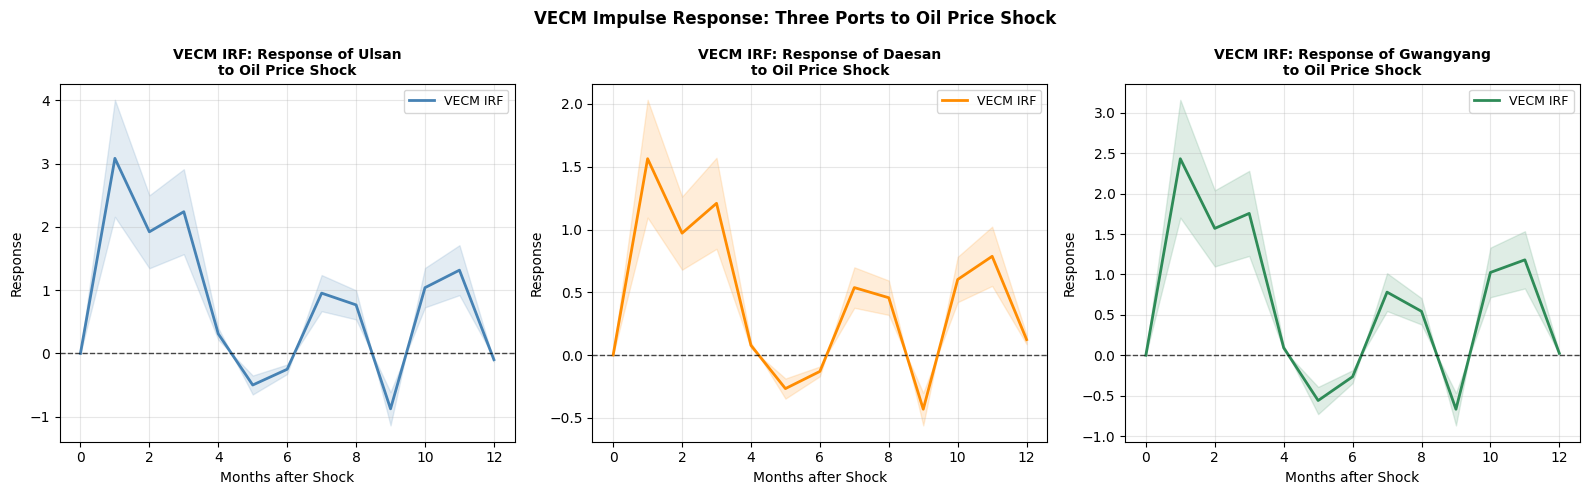


[VAR IRF vs VECM IRF 비교 포인트]
VAR IRF:  충격이 시간이 지나면 0으로 돌아옴
VECM IRF: 장기 균형이 있어서 새로운 수준으로 수렴할 수 있음
→ 두 그래프의 모양 차이를 비교해보세요.


In [ ]:

# %% [셀 16] VECM 기반 IRF
# -----------------------------------------------------------
# VECM 결과로도 IRF를 그릴 수 있습니다.
# VAR의 IRF와 비교해보면 차이가 보입니다.
# VECM의 IRF는 장기 균형 복귀 효과까지 반영되기 때문에
# 충격이 사라지지 않고 새로운 균형 수준으로 수렴하는 경우도 있습니다.

irf_vecm = vecm_result.irf(periods=12)

# 유가 충격에 대한 세 항만 반응
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

port_vars   = ['Ulsan', 'Daesan', 'Gwangyang']
port_colors = ['steelblue', 'darkorange', 'seagreen']

for ax, port, color in zip(axes, port_vars, port_colors):
    port_idx = port_names.index(port)
    oil_idx  = port_names.index('Oil_Price')

    # VECM IRF 값 추출
    irf_vals = irf_vecm.irfs[:, port_idx, oil_idx]
    time_ax  = range(len(irf_vals))

    ax.plot(time_ax, irf_vals,
            color=color, linewidth=2, label='VECM IRF')
    ax.axhline(y=0, color='black',
               linestyle='--', linewidth=1, alpha=0.7)
    ax.fill_between(time_ax,
                    irf_vals * 0.7,   # 간략 신뢰구간 (±30%)
                    irf_vals * 1.3,
                    alpha=0.15, color=color)
    ax.set_title(f'VECM IRF: Response of {port}\nto Oil Price Shock',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Months after Shock')
    ax.set_ylabel('Response')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('VECM Impulse Response: Three Ports to Oil Price Shock',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[VAR IRF vs VECM IRF 비교 포인트]")
print("VAR IRF:  충격이 시간이 지나면 0으로 돌아옴")
print("VECM IRF: 장기 균형이 있어서 새로운 수준으로 수렴할 수 있음")
print("→ 두 그래프의 모양 차이를 비교해보세요.")


In [ ]:

# %% [셀 17] 분석 결과 전체 요약
# -----------------------------------------------------------
# 오늘 분석한 내용 전체를 한 화면에 정리합니다.
# 이 요약이 논문 방법론·결과 파트의 뼈대가 됩니다.

print()
print("=" * 65)
print("       11회차 실습 결과 전체 요약")
print("=" * 65)
print()
print("[ 1단계: 단위근 검정 (ADF) ]")
for col in vars_use:
    p_orig = results_orig[col][0]
    p_diff = results_diff[col][0]
    orig = "정상" if p_orig < 0.05 else "비정상"
    diff = "정상" if p_diff < 0.05 else "비정상"
    order = "I(0)" if orig == "정상" else ("I(1)" if diff == "정상" else "I(2)+")
    print(f"  {col:<20}: {order}")

print()
print("[ 2단계: 요한슨 공적분 검정 ]")
print(f"  공적분 벡터 수: {coint_rank}개")
if coint_rank > 0:
    print("  → 장기 균형 관계 존재 → VECM 적용")
else:
    print("  → 장기 균형 관계 없음 → 차분 VAR 적용")

print()
print(f"[ 3단계: 최적 시차 선택 ]")
print(f"  선택된 시차: {selected_lag}기 (AIC/BIC 기준)")

print()
print("[ 4단계: 모델 적합 결과 ]")
if use_vecm:
    print("  사용 모델: VECM")
    print(f"  {'변수':<20} {'ECT 계수(α)':>14} {'반감기':>12}")
    print("  " + "-" * 48)
    for i, name in enumerate(port_names):
        coef = alpha[i, 0]
        if coef < 0 and abs(coef) < 1:
            hl = f"약 {np.log(0.5)/np.log(1+coef):.1f}개월"
        elif coef >= 0:
            hl = "발산"
        else:
            hl = "1개월 미만"
        print(f"  {name:<20} {coef:>14.4f} {hl:>12}")
else:
    print("  사용 모델: VAR (차분)")
    print(f"  시차: {selected_lag}기")

print()
print("[ 5단계: 주요 해석 ]")
print("  - IRF: 유가 충격 → 세 항만 반응 방향 및 지속 기간 확인")
print("  - FEVD: 물동량 변동의 원인 비율 분해")
if use_vecm:
    print("  - ECT: 장기 균형 이탈 시 교정 속도 확인")

print()
print("=" * 65)
print("  수업 전체 여정 완료")
print("=" * 65)
print()
print("  1회차:  데이터란 무엇인가")
print("  ...")
print("  8회차:  가설검정")
print("  9회차:  회귀분석 입문 (OLS)")
print("  10회차: 회귀 진단 + 시계열 기초 + 정상성")
print("  11회차: VAR + 공적분 + VECM   ← 오늘")
print()
print("  배운 것의 큰 그림:")
print("  데이터 이해 → 관계 파악 → 회귀 → 시계열 → VAR/VECM")
print("  이 흐름이 논문 분석 파트의 뼈대입니다.")
print("=" * 65)


       11회차 실습 결과 전체 요약

[ 1단계: 단위근 검정 (ADF) ]
  Ulsan               : I(1)
  Daesan              : I(1)
  Gwangyang           : I(1)
  Oil_Price           : I(1)

[ 2단계: 요한슨 공적분 검정 ]
  공적분 벡터 수: 1개
  → 장기 균형 관계 존재 → VECM 적용

[ 3단계: 최적 시차 선택 ]
  선택된 시차: 12기 (AIC/BIC 기준)

[ 4단계: 모델 적합 결과 ]
  사용 모델: VECM
  변수                        ECT 계수(α)          반감기
  ------------------------------------------------
  Ulsan                       -0.4382      약 1.2개월
  Daesan                      -0.2715      약 2.2개월
  Gwangyang                   -0.3601      약 1.6개월
  Oil_Price                    0.0632           발산

[ 5단계: 주요 해석 ]
  - IRF: 유가 충격 → 세 항만 반응 방향 및 지속 기간 확인
  - FEVD: 물동량 변동의 원인 비율 분해
  - ECT: 장기 균형 이탈 시 교정 속도 확인

  수업 전체 여정 완료

  1회차:  데이터란 무엇인가
  ...
  8회차:  가설검정
  9회차:  회귀분석 입문 (OLS)
  10회차: 회귀 진단 + 시계열 기초 + 정상성
  11회차: VAR + 공적분 + VECM   ← 오늘

  배운 것의 큰 그림:
  데이터 이해 → 관계 파악 → 회귀 → 시계열 → VAR/VECM
  이 흐름이 논문 분석 파트의 뼈대입니다.
